In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

In [8]:
def get_scheduler(
    t_T = 199,
    jump_len = 10,
    jump_n_sample = 5,
):
    """Obtain a sigma scheduler for the given parameters."""
    jumps = {} 
    for j in range(0, t_T - jump_len, jump_len): 
        jumps[j] = jump_n_sample - 1 

    t = t_T 
    ts = [] 
    while t >= 1: 
        t = t-1 
        ts.append(t)
        if jumps.get(t, 0) > 0: 
            jumps[t] = jumps[t] - 1 
            for _ in range(jump_len): 
                t=t+1 
                ts.append(t) 
    ts.append(-1)
    return ts

In [9]:
times = get_scheduler()
x = torch.rand((10,10))

# for t_last, t_cur in zip(times[:-1], times[1:]):
#     if t_cur < t_last:
#         # Apply reverse denoise
#         x = reverse_denoise(x, t, x_known)
#     else:
#         # Apply forward diffusion
#         x = forward_diffusion(x, t)

(0.0, 1718.0)

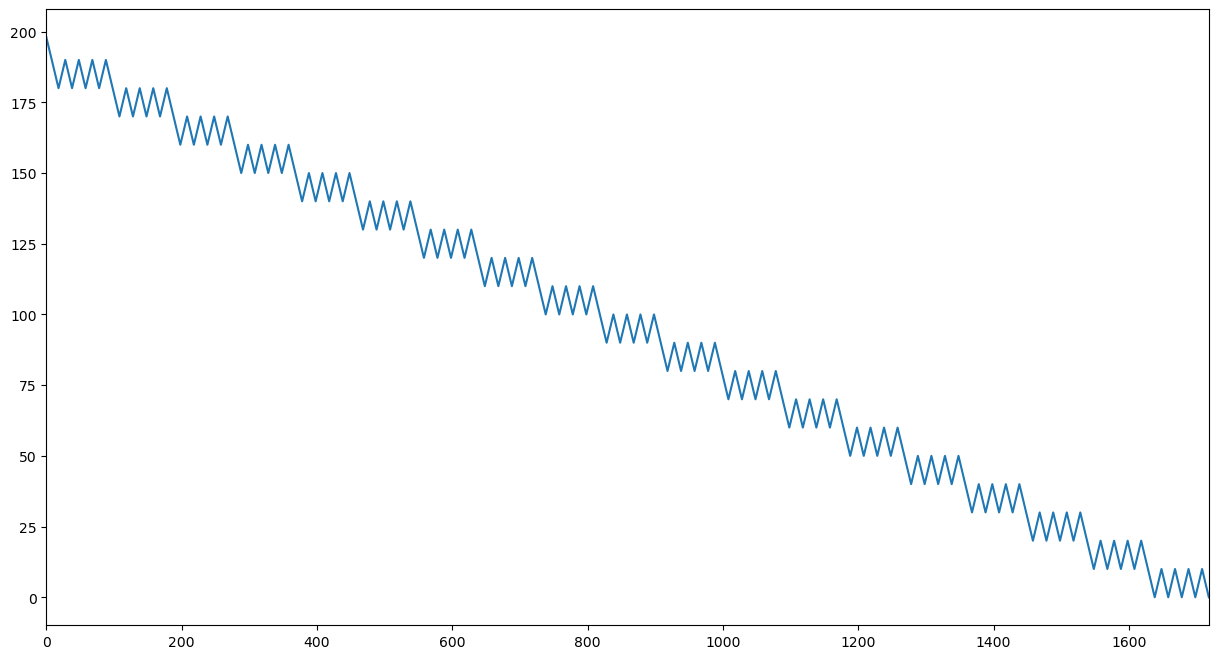

In [10]:
plt.figure(figsize=(15, 8))
plt.plot(times[:-1])
plt.xlim(0, len(times[:-1])-1)

In [170]:
np.max(199 - (np.array(times)+1))

199